# AI Crypto Hedge Fund — Часть 2

## Уровень 1. Базовая стратегия на одной паре (BTC/USDT)

Этот ноутбук — «витрина»: он импортирует логику из пакета `chf` (папка `src/chf`) и показывает результаты. Здесь мы реализуем **базовую стратегию** на пересечении скользящих средних и оцениваем её по метрикам доходности и риска.

Это эталон (*baseline*), который более умные агенты на следующих уровнях должны будут превзойти.

## Настройка
Подключаем библиотеки и наш пакет `chf`.

In [1]:
import sys
sys.path.insert(0, "src")  # чтобы ноутбук видел пакет chf из папки src/

import matplotlib.pyplot as plt
import pandas as pd

from chf.data.loader import load_ohlcv
from chf.strategies.moving_average import MovingAverageCross
from chf.services.backtest import run_backtest
from chf.services import metrics as M

print("Библиотеки подключены.")

Библиотеки подключены.


## 1. Загружаем данные
Берём дневные свечи BTC/USDT, скачанные скриптом `scripts/download_data.py`.

In [2]:
btc = load_ohlcv("BTC/USDT")
print(f"{len(btc)} строк, период с {btc.index.min().date()} по {btc.index.max().date()}")
btc[["open", "high", "low", "close", "volume"]].head()

1997 строк, период с 2021-01-01 по 2026-06-20


,open,high,low,close,volume
date,,,,,
2021-01-01 00:00:00+00:00,28923.63,29600.00,28624.57,29331.69,54182.925011
2021-01-02 00:00:00+00:00,29331.70,33300.00,28946.53,32178.33,129993.873362
2021-01-03 00:00:00+00:00,32176.45,34778.11,31962.99,33000.05,120957.566750
2021-01-04 00:00:00+00:00,33000.05,33600.00,28130.00,31988.71,140899.885690
2021-01-05 00:00:00+00:00,31989.75,34360.00,29900.00,33949.53,116049.997038


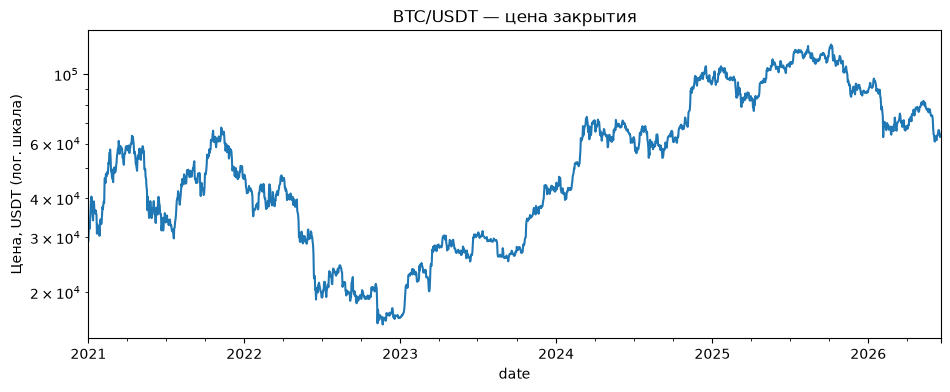

In [3]:
btc["close"].plot(figsize=(11, 4), title="BTC/USDT — цена закрытия", logy=True)
plt.ylabel("Цена, USDT (лог. шкала)")
plt.show()

## 2. Базовая стратегия: пересечение скользящих средних

**Идея.** Считаем две скользящие средние цены: «быструю» (короткое окно, напр. 20 дней) и «медленную» (длинное окно, напр. 50 дней).
- быстрая **выше** медленной → восходящий тренд → **держим лонг** (позиция = 1);
- быстрая **ниже** медленной → **выходим в кэш** (позиция = 0).

Правило простое и без обучения — поэтому идеально как точка отсчёта.

**Честность теста.** Сигнал по дню *t* исполняется только на следующий день *t+1* — иначе мы бы «подглядывали в будущее». Это зашито в движок (`shift(1)`). С каждой сделки вычитается комиссия 0.1%.

In [4]:
strategy = MovingAverageCross(fast=20, slow=50)
result = run_backtest(btc, strategy, cost=0.001)

print(f"Стратегия: {strategy.name}\n")
for name, value in result.metrics.items():
    print(f"{name:>14}: {value:.3f}")

Стратегия: MA(20,50)

  total_return: 0.116
          CAGR: 0.020
        sharpe: 0.239
       sortino: 0.351
  max_drawdown: -0.587


### Что означают метрики
- **total_return** — общая доходность за период (ROI). `0.5` = +50%.
- **CAGR** — среднегодовая доходность со сложным процентом.
- **sharpe** — доходность на единицу риска; > 1 считается хорошим.
- **max_drawdown** — глубочайшая просадка от пика до дна. `-0.4` = теряли 40%.

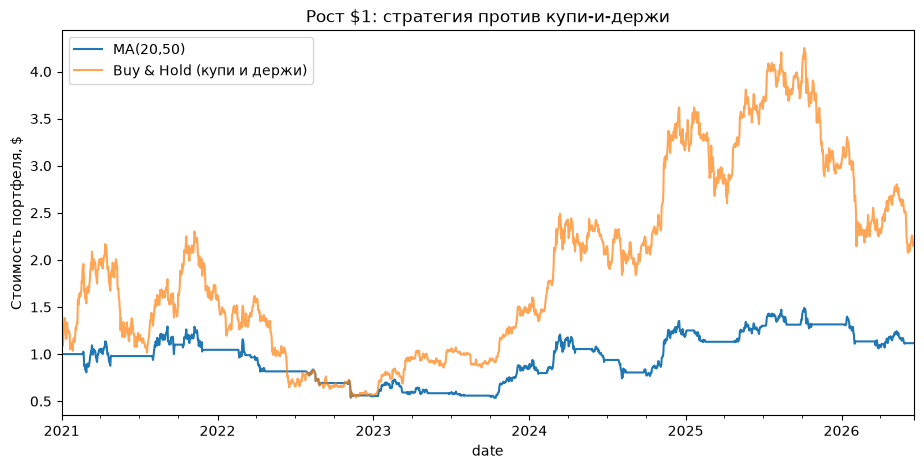

In [5]:
buy_hold = (1 + btc["close"].pct_change().fillna(0)).cumprod()

ax = result.equity_curve.plot(figsize=(11, 5), label=strategy.name)
buy_hold.plot(ax=ax, label="Buy & Hold (купи и держи)", alpha=0.7)
ax.set_title("Рост $1: стратегия против купи-и-держи")
ax.set_ylabel("Стоимость портфеля, $")
ax.legend()
plt.show()

## 3. Сравнение параметров
Разные окна скользящих средних против простого «купи и держи».

In [6]:
configs = [(10, 30), (20, 50), (50, 200)]
rows = []
for fast, slow in configs:
    r = run_backtest(btc, MovingAverageCross(fast, slow))
    rows.append({"strategy": f"MA({fast},{slow})", **r.metrics})

bh_returns = btc["close"].pct_change().fillna(0)
bh_equity = (1 + bh_returns).cumprod()
rows.append({
    "strategy": "Buy & Hold",
    "total_return": M.total_return(bh_returns),
    "CAGR": M.cagr(bh_returns),
    "sharpe": M.sharpe_ratio(bh_returns),
    "max_drawdown": M.max_drawdown(bh_equity),
})

pd.DataFrame(rows).set_index("strategy").round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
strategy,,,,,
"MA(10,30)",0.305,0.050,0.318,0.469,-0.636
"MA(20,50)",0.116,0.020,0.239,0.351,-0.587
"MA(50,200)",0.662,0.097,0.440,0.661,-0.448
Buy & Hold,1.178,0.153,0.535,NaN,-0.766


## 4. Вывод по Уровню 1

На **одном активе с сильным многолетним ростом** трендследящая стратегия проигрывает «купи и держи» по доходности и Sharpe — потому что в кэше она пропускает резкие отскоки. Зато она заметно **снижает просадку**. Это не провал: цель хедж-фонда — доходность *с поправкой на риск* и диверсификация, а не «обогнать одну монету». Дальше снимаем «жёсткость» правила и переходим к обучаемому агенту.

# Уровень 2. AI-агенты на одной паре (BTC/USDT)

Теперь правило 20/50 заменяем **обучаемым агентом**. Он сам ищет закономерности в данных и предсказывает направление цены. Отвечаем на ключевые вопросы задания:

- **Какие признаки?** импульс (доходности за 1/5/10 дней), волатильность, расстояние до средних, RSI, изменение объёма.
- **Целевая переменная?** вырастет ли цена завтра (1) или нет (0).
- **Как обучаем и тестируем?** хронологическое разбиение: учимся на прошлом, проверяемся на будущем (out-of-sample). Перемешивать нельзя — это временной ряд.

## 1. Честное разбиение: обучение и тест
Первые 70% истории — для обучения, последние 30% — для проверки. Модель **никогда** не видит тестовый период при обучении.

In [7]:
split_idx = int(len(btc) * 0.7)
split_date = btc.index[split_idx]
train_prices = btc.iloc[:split_idx]

print(f"Обучение: {train_prices.index.min().date()} → {train_prices.index.max().date()} ({len(train_prices)} дней)")
print(f"Тест (OOS): {split_date.date()} → {btc.index.max().date()} ({len(btc) - split_idx} дней)")

Обучение: 2021-01-01 → 2024-10-28 (1397 дней)
Тест (OOS): 2024-10-29 → 2026-06-20 (600 дней)


## 2. Признаки и целевая переменная
Посмотрим на таблицу признаков, которую агент использует как вход.

In [8]:
from chf.features import make_features, make_target

X = make_features(btc)
y = make_target(btc)
X.tail()

,ret_1,ret_5,ret_10,vol_10,vol_30,mom_20,mom_50,rsi_14,vol_change_5
date,,,,,,,,,
2026-06-16 00:00:00+00:00,-0.009856,0.032204,0.078680,0.019579,0.021922,-0.006317,-0.106351,47.451519,-0.177142
2026-06-17 00:00:00+00:00,-0.017748,0.014618,0.018591,0.017366,0.022040,-0.017181,-0.119376,51.966967,0.161712
2026-06-18 00:00:00+00:00,-0.024049,-0.023271,-0.002029,0.019197,0.022282,-0.033081,-0.137535,47.726123,0.700235
2026-06-19 00:00:00+00:00,0.009306,-0.033501,0.029385,0.017791,0.022281,-0.016271,-0.126444,60.069591,0.079102
2026-06-20 00:00:00+00:00,0.005541,-0.036677,0.038774,0.017648,0.022350,-0.003276,-0.118128,61.898807,-0.553081


## 3. ML-агент: случайный лес
Берём **случайный лес** (ансамбль неглубоких деревьев) — он устойчив к шуму и не требует масштабирования. Деревья неглубокие, листья крупные — это защита от переобучения на шумном рынке.

Агент обучается **только на train**, а затем строит сигналы по всей истории (признакам нужен «разогрев»). Оцениваем мы его **только на тестовом отрезке**.

In [9]:
from chf.strategies.ml import MLAgent

ml = MLAgent(train_prices)          # обучение только на train
result_ml = run_backtest(btc, ml)   # сигналы по всей истории

def metrics_on(returns):
    """Метрики по срезу доходностей (кривая капитала стартует с 1.0)."""
    equity = (1 + returns).cumprod()
    return M.summary(returns, equity)

print("ML-агент обучен. Признаки:", ml.feature_names)

ML-агент обучен. Признаки: ['ret_1', 'ret_5', 'ret_10', 'vol_10', 'vol_30', 'mom_20', 'mom_50', 'rsi_14', 'vol_change_5']


## 4. Сравнение на тесте (out-of-sample)
Все три подхода — на одном и том же **тестовом** отрезке, честно.

In [10]:
ma = MovingAverageCross(50, 200)
result_ma = run_backtest(btc, ma)
test_asset_ret = btc.loc[split_date:, "close"].pct_change().fillna(0)

rows = [
    {"strategy": ml.name,      **metrics_on(result_ml.returns.loc[split_date:])},
    {"strategy": ma.name,      **metrics_on(result_ma.returns.loc[split_date:])},
    {"strategy": "Buy & Hold", **metrics_on(test_asset_ret)},
]
pd.DataFrame(rows).set_index("strategy").round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
strategy,,,,,
ML (RandomForest),-0.226,-0.144,-0.283,-0.401,-0.433
"MA(50,200)",-0.049,-0.030,0.072,0.105,-0.373
Buy & Hold,-0.122,-0.076,0.053,0.077,-0.512


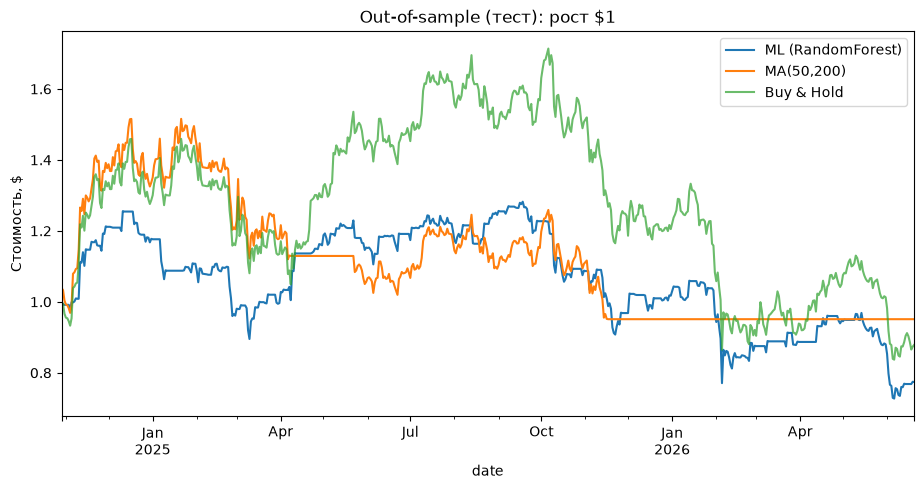

In [11]:
curve_ml = (1 + result_ml.returns.loc[split_date:]).cumprod()
curve_ma = (1 + result_ma.returns.loc[split_date:]).cumprod()
curve_bh = (1 + test_asset_ret).cumprod()

ax = curve_ml.plot(figsize=(11, 5), label=ml.name)
curve_ma.plot(ax=ax, label=ma.name)
curve_bh.plot(ax=ax, label="Buy & Hold", alpha=0.7)
ax.set_title("Out-of-sample (тест): рост $1")
ax.set_ylabel("Стоимость, $")
ax.legend()
plt.show()

## 5. Проверка: это не случайность?
Два теста: (а) точность предсказания направления против «угадывания большинства»; (б) сравнение Sharpe нашего агента с сотнями **случайных** стратегий.

In [12]:
from sklearn.metrics import accuracy_score

X_test = make_features(btc).loc[split_date:].dropna()
y_test = make_target(btc).loc[X_test.index]
pred = ml.model.predict(X_test[ml.feature_names])

acc = accuracy_score(y_test, pred)
majority = max(y_test.mean(), 1 - y_test.mean())
print(f"Точность направления (тест): {acc:.1%}")
print(f"Угадывание большинства:      {majority:.1%}")

Точность направления (тест): 49.0%
Угадывание большинства:      50.7%


In [13]:
import numpy as np

rng = np.random.default_rng(42)
n_random = 300
random_sharpes = []
for _ in range(n_random):
    pos = pd.Series(rng.integers(0, 2, len(test_asset_ret)), index=test_asset_ret.index)
    pos = pos.shift(1).fillna(0)
    random_sharpes.append(M.sharpe_ratio(pos * test_asset_ret))
random_sharpes = np.array(random_sharpes)

ml_sharpe = metrics_on(result_ml.returns.loc[split_date:])["sharpe"]
better_than = (random_sharpes < ml_sharpe).mean() * 100
print(f"Sharpe ML-агента (тест): {ml_sharpe:.3f}")
print(f"Лучше, чем {better_than:.0f}% из {n_random} случайных стратегий")

Sharpe ML-агента (тест): -0.283
Лучше, чем 28% из 300 случайных стратегий


## 6. Выводы по Уровню 2

**Про точность.** Предсказывать дневное направление цены очень трудно — точность около 50% это норма даже для хороших моделей. Но это не делает агента бесполезным: ценность не в проценте угадываний, а в том, чтобы быть в рынке во время крупных движений и в стороне во время падений. Поэтому судим по **доходности и риску**, а не по accuracy.

**Как часто переобучать?** В бою модель устаревает: рынок меняется. Правильно — периодически переобучать на скользящем окне (напр. раз в месяц/квартал). Следующее улучшение методологии — *walk-forward* (много последовательных переобучений вместо одного разбиения).

**Почему эти метрики?** Хедж-фонд живёт за счёт доходности **с поправкой на риск** и способности пережить просадку. Поэтому Sharpe и max_drawdown важнее «голой» доходности.

---
**Дальше:** добавим эконометрику (GARCH для оценки волатильности и управления размером позиции), а затем перейдём к **Уровню 3** — портфелю из нескольких монет.

# Уровень 3. Портфель из нескольких монет

Урок Уровней 1-2: предсказать одну монету трудно. Реальное преимущество хедж-фонда — **диверсификация**: распределить капитал между активами так, чтобы при той же доходности риск был ниже.

Ключевые понятия (теория Марковица):
- **Оптимальный портфель** — набор весов с лучшим соотношением доходность/риск.
- **Эффективная граница** — портфели, дающие максимум доходности при заданном риске.
- **Max Sharpe** — лучший риск-адъюстированный портфель; **Min Variance** — самый «спокойный».

## 1. Монеты и их доходности
Берём 7 популярных монет и считаем их дневные доходности.

In [14]:
from chf.data.loader import load_close_prices
from chf.services import portfolio as port

coins = ["BTC/USDT", "ETH/USDT", "SOL/USDT", "BNB/USDT", "ZEC/USDT", "DOGE/USDT"]
prices = load_close_prices(coins)
returns = prices.pct_change().dropna()
returns.tail()

,BTC/USDT,ETH/USDT,SOL/USDT,BNB/USDT,ZEC/USDT,DOGE/USDT
date,,,,,,
2026-06-16 00:00:00+00:00,-0.009856,-0.001748,-0.006218,-0.020927,-0.026201,-0.011005
2026-06-17 00:00:00+00:00,-0.017748,-0.023642,-0.019995,-0.005472,-0.055158,-0.014225
2026-06-18 00:00:00+00:00,-0.024049,-0.022558,-0.032477,-0.038479,-0.044821,-0.028046
2026-06-19 00:00:00+00:00,0.009306,0.000047,0.000430,0.005082,0.045981,0.000599
2026-06-20 00:00:00+00:00,0.005541,0.009292,0.027674,0.007550,-0.024434,-0.004427


### Корреляции
Крипто-монеты сильно связаны (растут и падают вместе), но **не на 100%** — именно эта неполная связь и даёт пользу от диверсификации.

In [15]:
returns.corr().round(2)

,BTC/USDT,ETH/USDT,SOL/USDT,BNB/USDT,ZEC/USDT,DOGE/USDT
BTC/USDT,1.00,0.81,0.61,0.64,0.55,0.38
ETH/USDT,0.81,1.00,0.66,0.65,0.56,0.35
SOL/USDT,0.61,0.66,1.00,0.57,0.46,0.26
BNB/USDT,0.64,0.65,0.57,1.00,0.47,0.24
ZEC/USDT,0.55,0.56,0.46,0.47,1.00,0.26
DOGE/USDT,0.38,0.35,0.26,0.24,0.26,1.00


## 2. Честное разбиение
Веса портфеля считаем на **train**, а проверяем — на отложенном **test**. Оптимизировать и проверять на одних данных нельзя: «оптимальный» портфель всегда красив на прошлом.

In [16]:
split_idx = int(len(returns) * 0.7)
train_returns = returns.iloc[:split_idx]
test_returns = returns.iloc[split_idx:]
mean, cov = port.annualized_stats(train_returns)

print(f"Оценка весов (train): {train_returns.index.min().date()} → {train_returns.index.max().date()}")
print(f"Проверка (test):      {test_returns.index.min().date()} → {test_returns.index.max().date()}")

Оценка весов (train): 2021-01-02 → 2024-10-29
Проверка (test):      2024-10-30 → 2026-06-20


## 3. Оптимальные портфели
Считаем три набора весов: максимум Sharpe, минимум риска и равные доли (простой ориентир).

In [17]:
w_ms = port.max_sharpe(mean, cov)
w_mv = port.min_variance(mean, cov)
w_eq = pd.Series(1 / len(coins), index=mean.index)

weights = pd.DataFrame({"Max Sharpe": w_ms, "Min Variance": w_mv, "Equal weight": w_eq})
weights.round(3)

,Max Sharpe,Min Variance,Equal weight
BTC/USDT,0.000,0.952,0.167
ETH/USDT,0.000,0.000,0.167
SOL/USDT,0.586,0.000,0.167
BNB/USDT,0.265,0.048,0.167
ZEC/USDT,0.000,0.000,0.167
DOGE/USDT,0.149,0.000,0.167


In [18]:
perf = {}
for name, w in [("Max Sharpe", w_ms), ("Min Variance", w_mv), ("Equal weight", w_eq)]:
    r, v, s = port.portfolio_performance(w, mean, cov)
    perf[name] = {"доходность": r, "волатильность": v, "sharpe": s}
pd.DataFrame(perf).T.round(3)

,доходность,волатильность,sharpe
Max Sharpe,1.782,1.016,1.755
Min Variance,0.466,0.624,0.746
Equal weight,1.158,0.854,1.355


### Эффективная граница
Серое облако — тысячи случайных портфелей. Звёзды — наши оптимальные. Ромбы — отдельные монеты. Видно, что портфели уходят **левее** (меньше риск) отдельных монет — это и есть диверсификация.

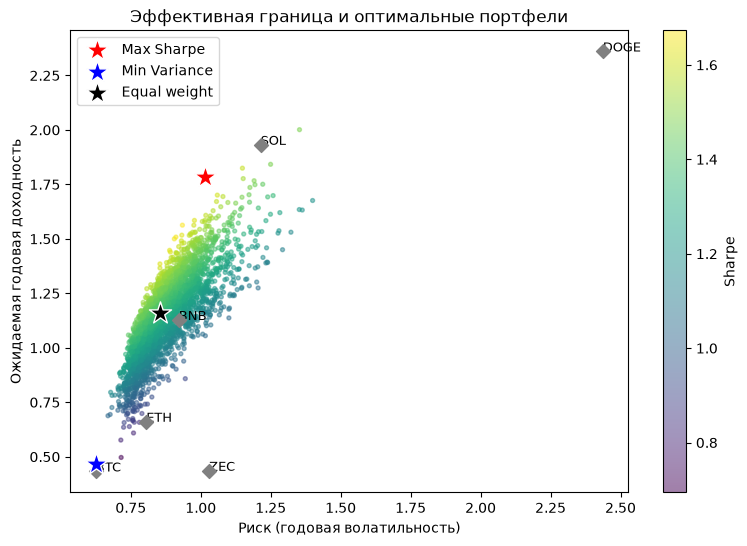

In [19]:
import numpy as np

rr, vv, ss = port.random_portfolios(3000, mean, cov)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(vv, rr, c=ss, cmap="viridis", s=8, alpha=0.5)
plt.colorbar(sc, label="Sharpe")

for label, w, color in [("Max Sharpe", w_ms, "red"), ("Min Variance", w_mv, "blue"), ("Equal weight", w_eq, "black")]:
    r, v, s = port.portfolio_performance(w, mean, cov)
    ax.scatter(v, r, c=color, marker="*", s=280, edgecolors="white", label=label, zorder=5)

for coin in mean.index:
    v = float(np.sqrt(cov.loc[coin, coin]))
    ax.scatter(v, mean[coin], marker="D", s=50, color="grey", zorder=4)
    ax.annotate(coin.split("/")[0], (v, mean[coin]), fontsize=9)

ax.set_xlabel("Риск (годовая волатильность)")
ax.set_ylabel("Ожидаемая годовая доходность")
ax.set_title("Эффективная граница и оптимальные портфели")
ax.legend()
plt.show()

## 4. Честная проверка на тесте
Берём веса, посчитанные на train, **фиксируем** их и смотрим, как они отработали бы на тесте — против простого «держим только BTC».

In [20]:
results = {}
for name, w in [("Max Sharpe", w_ms), ("Min Variance", w_mv), ("Equal weight", w_eq)]:
    results[name] = metrics_on(port.portfolio_returns(w, test_returns))

results["Только BTC"] = metrics_on(test_returns["BTC/USDT"])
pd.DataFrame(results).T.round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
Max Sharpe,-0.438,-0.296,-0.165,-0.233,-0.679
Min Variance,-0.113,-0.070,0.064,0.092,-0.512
Equal weight,0.337,0.194,0.597,0.869,-0.494
Только BTC,-0.122,-0.076,0.053,0.077,-0.512


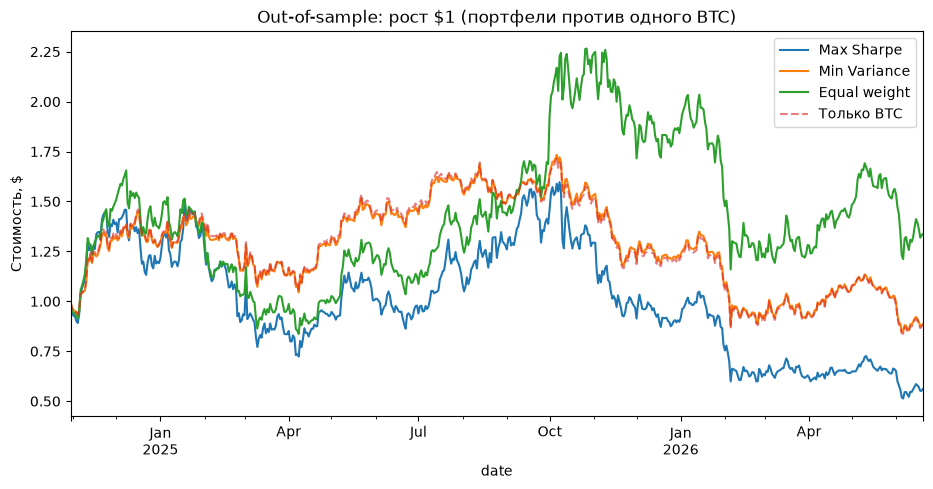

In [21]:
ax = None
for name, w in [("Max Sharpe", w_ms), ("Min Variance", w_mv), ("Equal weight", w_eq)]:
    curve = (1 + port.portfolio_returns(w, test_returns)).cumprod()
    ax = curve.plot(figsize=(11, 5), label=name, ax=ax)

btc_curve = (1 + test_returns["BTC/USDT"]).cumprod()
btc_curve.plot(ax=ax, label="Только BTC", alpha=0.6, linestyle="--")
ax.set_title("Out-of-sample: рост $1 (портфели против одного BTC)")
ax.set_ylabel("Стоимость, $")
ax.legend()
plt.show()

## 5. Выводы по Уровню 3

**Что такое оптимальный портфель.** Это веса на верхней кромке «облака» (эффективной границе): при заданном риске — максимум доходности. Диверсификация работает, потому что монеты связаны не идеально — смесь снижает риск сильнее, чем теряет в доходности.

**Снова про честность.** Max Sharpe считается по прошлой средней доходности, а она очень шумная — поэтому такой портфель часто «подгоняется» под прошлых победителей и хуже держится на тесте. Min Variance и равные веса обычно устойчивее. Это та же мысль, что на Уровне 2: переобучение наказывается и в портфелях.

**Метрики.** Годовая доходность, волатильность, Sharpe и просадка — всё то же, чем меряем риск-адъюстированный результат.

---
**Дальше — Уровень 4:** веса не должны быть вечными. Рынок меняется, поэтому портфель нужно периодически **перебалансировать** по правилам.

# Уровень 4. Динамическая ребалансировка

В Уровне 3 веса были посчитаны один раз и заморожены. Но рынок меняется — «спокойные» вчера монеты сегодня могут стать бурными. Решение: периодически **пересчитывать веса по свежим данным**.

Виды ребалансировки:
- **по времени** — раз в N дней (реализуем её);
- **по отклонению весов** — когда доля монеты уехала от цели больше чем на X%;
- **по сигналам** — от агентов или риск-метрик (мостик к Уровню 5).

Делаем walk-forward: каждые N дней пересчитываем веса **только по прошлому окну** (без подглядывания вперёд). С каждой сделки берётся комиссия — поэтому слишком частый ребаланс может «съесть» прибыль.

## 1. Статика против динамики
Сравним **замороженный** Min Variance из Уровня 3 с **динамическим** — где ковариация пересчитывается каждые 30 дней по последним 180 дням.

In [22]:
from chf.services.rebalancing import rebalance_backtest, equal_weights, min_var_weights

dyn_mv_net, dyn_mv_w, n_reb = rebalance_backtest(returns, min_var_weights, lookback=180, rebalance_every=30)
dyn_eq_net, _, _ = rebalance_backtest(returns, equal_weights, lookback=180, rebalance_every=30)

print(f"Динамический Min Variance: {n_reb} ребалансировок за весь период")

Динамический Min Variance: 61 ребалансировок за весь период


In [23]:
results4 = {
    "Min Var (статика)":  metrics_on(port.portfolio_returns(w_mv, test_returns)),
    "Min Var (динамика)": metrics_on(dyn_mv_net.loc[split_date:]),
    "Equal weight":       metrics_on(dyn_eq_net.loc[split_date:]),
    "Только BTC":         metrics_on(test_returns["BTC/USDT"]),
}
pd.DataFrame(results4).T.round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
Min Var (статика),-0.113,-0.070,0.064,0.092,-0.512
Min Var (динамика),0.147,0.087,0.411,0.586,-0.500
Equal weight,0.376,0.214,0.624,0.908,-0.494
Только BTC,-0.122,-0.076,0.053,0.077,-0.512


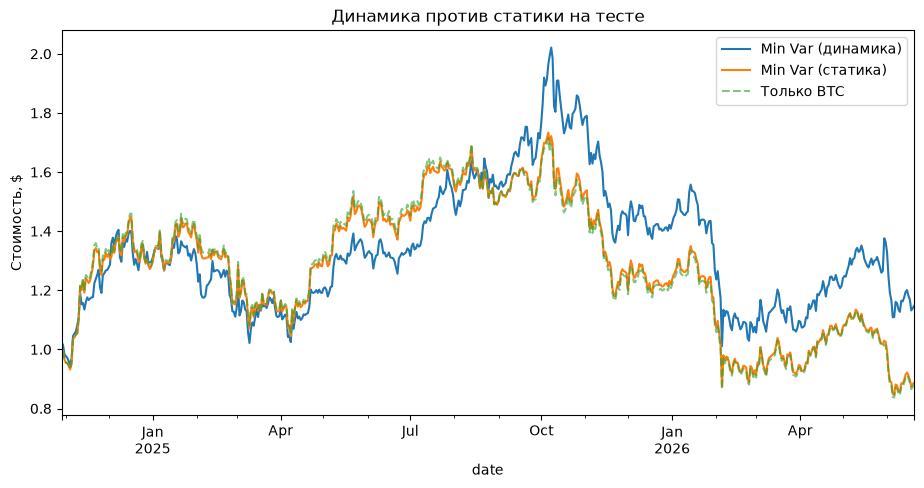

In [24]:
ax = (1 + dyn_mv_net.loc[split_date:]).cumprod().plot(figsize=(11, 5), label="Min Var (динамика)")
(1 + port.portfolio_returns(w_mv, test_returns)).cumprod().plot(ax=ax, label="Min Var (статика)")
(1 + test_returns["BTC/USDT"]).cumprod().plot(ax=ax, label="Только BTC", alpha=0.6, linestyle="--")
ax.set_title("Динамика против статики на тесте")
ax.set_ylabel("Стоимость, $")
ax.legend()
plt.show()

## 2. Как часто ребалансировать? Адаптивность против издержек
Чаще ребаланс = быстрее адаптация, но больше сделок и комиссий. Смотрим на результат **после издержек** и на число ребалансировок.

In [25]:
freq_rows = []
for every in [7, 30, 90, 180]:
    net, _, n = rebalance_backtest(returns, min_var_weights, lookback=180, rebalance_every=every)
    freq_rows.append({"ребаланс_раз_в_дней": every, "ребалансировок": n, **metrics_on(net.loc[split_date:])})
pd.DataFrame(freq_rows).set_index("ребаланс_раз_в_дней").round(3)

,ребалансировок,total_return,CAGR,sharpe,sortino,max_drawdown
ребаланс_раз_в_дней,,,,,,
7,260,0.115,0.068,0.372,0.531,-0.491
30,61,0.147,0.087,0.411,0.586,-0.500
90,21,0.001,0.001,0.230,0.325,-0.519
180,11,0.064,0.038,0.312,0.442,-0.521


## 3. Стресс-тест: кризисы
Динамическая стратегия честна на всём периоде (каждый день использует только прошлое), поэтому проверим её на реальных обвалах: **LUNA/UST** (май 2022), **FTX** (ноябрь 2022) и **крах 10/10** (октябрь 2025 — рекордные ликвидации на ~$19 млрд, усиленные депегом USDe на Binance).

Важно: крах 10/10 попадает в **тестовый** период — это честный out-of-sample стресс. Данные дневные, поэтому таблица отражает движение по закрытию дня, а не внутридневные «фитили» (в моменте падение было резче). Смотрим, сколько каждый подход потерял за окно кризиса.

In [26]:
crises = {
    "LUNA/UST (май 2022)":   ("2022-05-07", "2022-05-31"),
    "FTX (ноя 2022)":        ("2022-11-01", "2022-11-30"),
    "Крах 10/10 (окт 2025)": ("2025-10-01", "2025-10-31"),
}
strategies = {
    "Min Var (динамика)":      dyn_mv_net,
    "Equal weight (динамика)": dyn_eq_net,
    "Только BTC":              returns["BTC/USDT"],
}

rows = []
for cname, (start, end) in crises.items():
    row = {"кризис": cname}
    for sname, r in strategies.items():
        window = r.loc[start:end]
        row[sname] = (1 + window).prod() - 1   # доходность за окно кризиса
    rows.append(row)

pd.DataFrame(rows).set_index("кризис").round(3)

,Min Var (динамика),Equal weight (динамика),Только BTC
кризис,,,
LUNA/UST (май 2022),-0.121,-0.261,-0.117
FTX (ноя 2022),-0.133,-0.222,-0.162
Крах 10/10 (окт 2025),0.038,0.321,-0.039


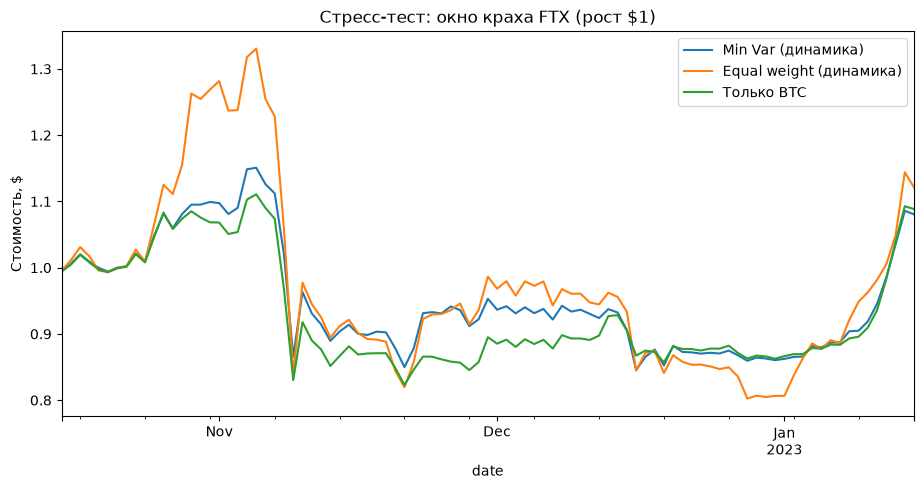

In [27]:
start, end = "2022-10-15", "2023-01-15"
ax = None
for name, r in [("Min Var (динамика)", dyn_mv_net), ("Equal weight (динамика)", dyn_eq_net), ("Только BTC", returns["BTC/USDT"])]:
    ax = (1 + r.loc[start:end]).cumprod().plot(figsize=(11, 5), label=name, ax=ax)
ax.set_title("Стресс-тест: окно краха FTX (рост $1)")
ax.set_ylabel("Стоимость, $")
ax.legend()
plt.show()

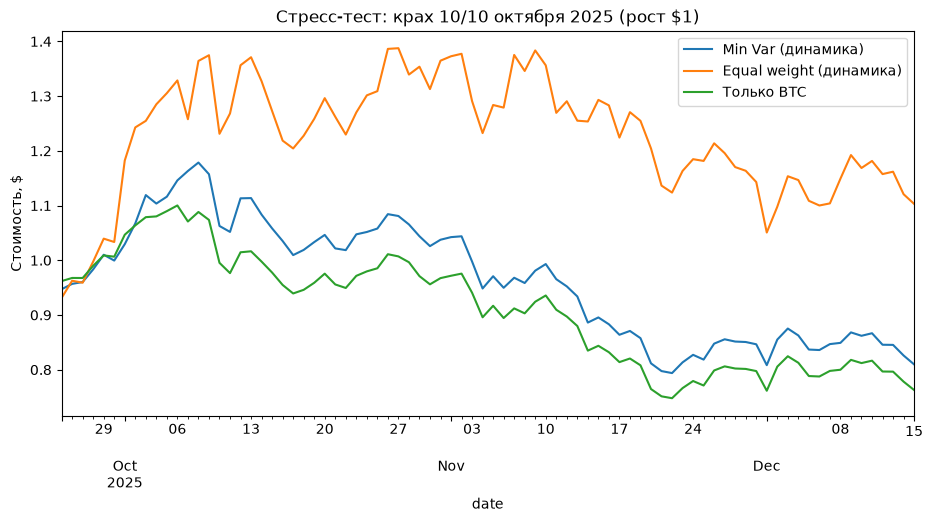

In [28]:
start, end = "2025-09-25", "2025-12-15"
ax = None
for name, r in [("Min Var (динамика)", dyn_mv_net), ("Equal weight (динамика)", dyn_eq_net), ("Только BTC", returns["BTC/USDT"])]:
    ax = (1 + r.loc[start:end]).cumprod().plot(figsize=(11, 5), label=name, ax=ax)
ax.set_title("Стресс-тест: крах 10/10 октября 2025 (рост $1)")
ax.set_ylabel("Стоимость, $")
ax.legend()
plt.show()

## 4. Выводы по Уровню 4

**Зачем динамика.** Замороженные веса устаревают: оценка риска, сделанная на старых данных, перестаёт соответствовать рынку. Пересчёт на скользящем окне держит портфель «в форме».

**Как выбрать частоту.** Это компромисс: чаще — адаптивнее, но дороже (комиссии и проскальзывание). Выбираем по **чистому** (после издержек) out-of-sample Sharpe, поглядывая на оборот. Часто оказывается, что умеренная частота (раз в месяц/квартал) лучше ежедневной — лишние сделки только жгут деньги.

**Умнее по времени.** Ребаланс «по отклонению весов» (только когда доля уехала на X%) экономит на сделках в спокойные периоды. А ребаланс «по сигналам/риску» (уводим капитал в кэш при росте волатильности) — это уже мостик к **риск-агенту**.

---
**Дальше — Уровень 5:** масштабируем до 100+ пар. Монеты отбираем **по правилу** (не руками!), добавляем риск-агента и «стоп-сигналы».

# Уровень 5. Масштаб: 100+ монет

До сих пор монеты выбирались руками — для настоящего фонда так нельзя: это подгонка задним числом. Здесь работаем со вселенной из 120 монет и **не выбираем их вручную**.

Главная сложность: у монет разная длина истории, поэтому общий период через `dropna` не годится. Решение — отбор **на каждую дату** (point-in-time): берём только монеты, которые на тот момент уже существовали и торговались достаточно долго. Это исключает и подглядывание в будущее, и survivorship bias.

Стратегия Уровня 5:
- **Отбор по правилу:** из «зрелых» монет берём топ-15 по моментуму за 90 дней;
- **веса:** равные (надёжнее оптимизации — вывод Уровня 3);
- **риск-агент (стоп-сигнал):** если рынок в нисходящем режиме (BTC ниже 100-дневной средней) — уходим в кэш; прямая защита от системных крахов вроде 10/10;
- **ребаланс** раз в 30 дней (оптимум Уровня 4).

In [29]:
from chf.services.universe import load_universe_prices, universe_backtest

uni = load_universe_prices()
hist = uni.notna().sum()
print(f"Монет во вселенной: {uni.shape[1]}")
print(f"История на монету: медиана {int(hist.median())} дней, мин {int(hist.min())}, макс {int(hist.max())}")

Монет во вселенной: 120
История на монету: медиана 921 дней, мин 3, макс 1997


## 1. Бэктест: с риск-агентом и без
Сравним стратегию со «стоп-сигналом» и без него — и обе против простого «держим BTC».

In [30]:
net_risk,   W_risk,   info_risk   = universe_backtest(uni, use_risk_agent=True)
net_norisk, W_norisk, info_norisk = universe_backtest(uni, use_risk_agent=False)

print(f"С риск-агентом: в среднем держим {info_risk['avg_holdings']:.0f} монет, "
      f"в кэше {info_risk['pct_in_cash']:.0%} ребалансов из {info_risk['n_rebalances']}")

u_results = {
    "Топ-15 momentum + риск-агент": metrics_on(net_risk.loc[split_date:]),
    "Топ-15 momentum (без агента)": metrics_on(net_norisk.loc[split_date:]),
    "Только BTC":                   metrics_on(returns["BTC/USDT"].loc[split_date:]),
}
pd.DataFrame(u_results).T.round(3)

С риск-агентом: в среднем держим 8 монет, в кэше 49% ребалансов из 61


,total_return,CAGR,sharpe,sortino,max_drawdown
Топ-15 momentum + риск-агент,-0.535,-0.372,-0.439,-0.592,-0.751
Топ-15 momentum (без агента),-0.622,-0.447,-0.461,-0.624,-0.821
Только BTC,-0.087,-0.054,0.106,0.154,-0.512


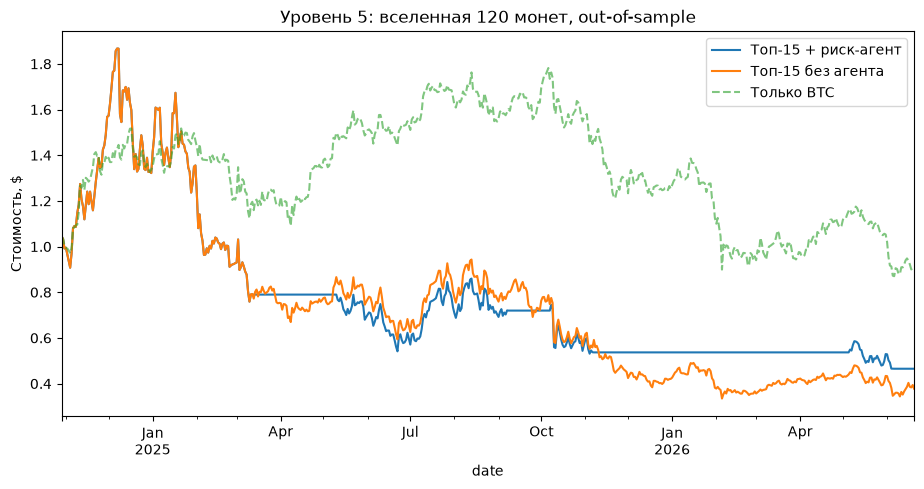

In [31]:
ax = (1 + net_risk.loc[split_date:]).cumprod().plot(figsize=(11, 5), label="Топ-15 + риск-агент")
(1 + net_norisk.loc[split_date:]).cumprod().plot(ax=ax, label="Топ-15 без агента")
(1 + returns["BTC/USDT"].loc[split_date:]).cumprod().plot(ax=ax, label="Только BTC", alpha=0.6, linestyle="--")
ax.set_title("Уровень 5: вселенная 120 монет, out-of-sample")
ax.set_ylabel("Стоимость, $")
ax.legend()
plt.show()

## 2. Помог ли риск-агент в крахах?
Сравним просадку стратегии в окнах FTX и 10/10 — со «стоп-сигналом» и без.

In [32]:
u_crises = {
    "FTX (ноя 2022)":        ("2022-11-01", "2022-11-30"),
    "Крах 10/10 (окт 2025)": ("2025-10-01", "2025-10-31"),
}
rows = []
for cname, (s, e) in u_crises.items():
    rows.append({
        "кризис":         cname,
        "с риск-агентом": (1 + net_risk.loc[s:e]).prod() - 1,
        "без агента":     (1 + net_norisk.loc[s:e]).prod() - 1,
        "Только BTC":     (1 + returns["BTC/USDT"].loc[s:e]).prod() - 1,
    })
pd.DataFrame(rows).set_index("кризис").round(3)

,с риск-агентом,без агента,Только BTC
кризис,,,
FTX (ноя 2022),0.000,-0.097,-0.162
Крах 10/10 (окт 2025),-0.209,-0.179,-0.039


## 3. Выводы по Уровню 5

**Масштаб без подгонки.** Монеты отбираются автоматически, по правилу и point-in-time — нет ни ручного выбора, ни survivorship bias. Это честный способ работать со 100+ парами.

**Риск-агент — это страховка, а не ускоритель.** Уход в кэш в нисходящем режиме снижает просадку в крахах ценой части роста. Именно так и работают «стоп-сигналы» / fail-safes: они оптимизируют не доходность, а выживание.

**Что нужно в продакшене (мониторинг и аварийные механизмы):** контроль ликвидности и проскальзывания, лимиты на размер позиции, аварийная остановка при сбое данных или биржи (вспомни 10/10 — отказ инфраструктуры Binance), алерты на отклонение реального портфеля от целевого.

**Честность результата.** Если стратегия не обгоняет BTC out-of-sample — это нормальный итог. Он показывает, как трудно стабильно бить рынок, и что ценность системы — в управлении риском, а не в «магии доходности». Это сквозная мысль всего проекта: честная проверка важнее красивых цифр.

# Бонус: эдж — это размер позиции, а не сигнал?

Гипотеза: у MA-стратегии (Уровень 1) преимущество не в средней доходности, а в **снижении просадок**. А раз компаундированный рост ≈ μ − σ²/2, то срезав волатильность и добавив управление размером позиции, можно обогнать «купи и держи» по сложному проценту.

Проверяем честно, out-of-sample, после издержек. На сигнал MA(50,200) накладываем два классических правила размера:
- **вол-таргетинг** — держим постоянную целевую волатильность (плечо вверх в спокойствие, вниз в бурю), лимит плеча ×2;
- **½ Келли** — ставим половину оптимума μ/σ² (дробный — потому что оценки шумные и полный Келли переразмеривает), лимит ×2.

Важно помнить: сайзинг — это **рычаг на эдж, а не источник эджа**. Если эджа нет, Келли стремится к нулю.

In [33]:
from chf.strategies.moving_average import MovingAverageCross
from chf.services.backtest import run_backtest
from chf.services.sizing import SizedStrategy, vol_target_size, fractional_kelly_size

ma       = MovingAverageCross(50, 200)
ma_vol   = SizedStrategy(ma, vol_target_size,       name="MA + вол-таргет")
ma_kelly = SizedStrategy(ma, fractional_kelly_size, name="MA + ½ Келли")

sized = {
    "Buy & Hold":        btc["close"].pct_change().fillna(0.0),
    "MA (без сайзинга)": run_backtest(btc, ma).returns,
    "MA + вол-таргет":   run_backtest(btc, ma_vol).returns,
    "MA + ½ Келли":      run_backtest(btc, ma_kelly).returns,
}
pd.DataFrame({k: metrics_on(v.loc[split_date:]) for k, v in sized.items()}).T.round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
Buy & Hold,-0.087,-0.054,0.106,0.154,-0.512
MA (без сайзинга),-0.049,-0.030,0.072,0.105,-0.373
MA + вол-таргет,-0.131,-0.082,0.005,0.007,-0.435
MA + ½ Келли,0.488,0.273,0.732,1.190,-0.392


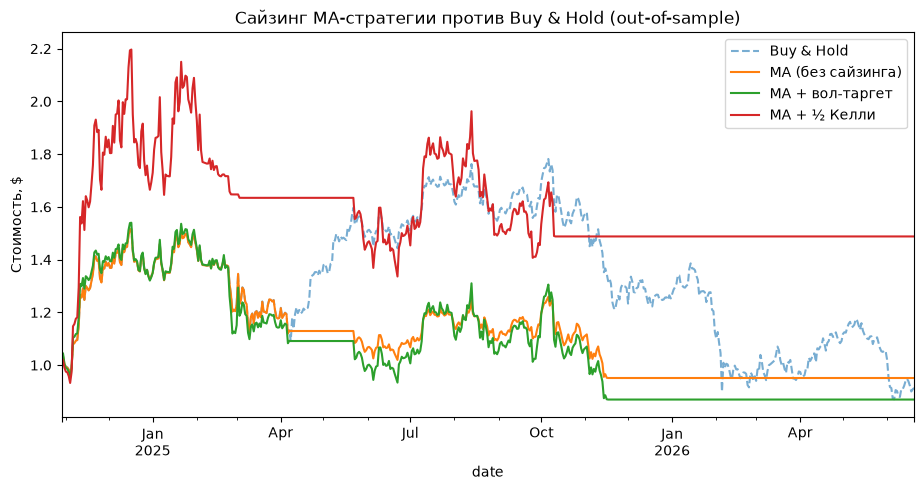

In [34]:
ax = None
for name, r in sized.items():
    style = {"linestyle": "--", "alpha": 0.6} if name == "Buy & Hold" else {}
    ax = (1 + r.loc[split_date:]).cumprod().plot(figsize=(11, 5), label=name, ax=ax, **style)
ax.set_title("Сайзинг MA-стратегии против Buy & Hold (out-of-sample)")
ax.set_ylabel("Стоимость, $")
ax.legend()
plt.show()

In [35]:
# Сколько плеча держим и какой оборот (издержки сайзинга)
for name, strat in [("MA + вол-таргет", ma_vol), ("MA + ½ Келли", ma_kelly)]:
    pos = strat.generate_signals(btc).shift(1).fillna(0.0).loc[split_date:]
    in_pos = pos[pos > 0]
    print(f"{name}: среднее плечо в позиции {in_pos.mean():.2f}, "
          f"доля дней в рынке {len(in_pos) / len(pos):.0%}, оборот {pos.diff().abs().sum():.0f}")

MA + вол-таргет: среднее плечо в позиции 1.31, доля дней в рынке 56%, оборот 15
MA + ½ Келли: среднее плечо в позиции 1.77, доля дней в рынке 44%, оборот 31


## Вывод по бонусу

**Сайзинг — рычаг, а не магия.** Темп роста при оптимальном Келли ≈ Sharpe² / 2 — то есть размер позиции усиливает уже существующий эдж (квадратично), но из нулевого эджа прибыль не создаёт.

**Где сайзинг реально помогает MA:** превращает снижение просадок в рост по сложному проценту через вол-таргетинг и безопасное плечо. Если в таблице выше сайзинг обогнал Buy & Hold по Sharpe/просадке — гипотеза подтвердилась; если нет — частые причины: издержки от переразметки размера (смотри оборот) либо сильно бычий период, где полное удержание выигрывает.

**Почему ½ Келли, а не полный.** Оценки μ и σ шумные → полный Келли систематически переразмеривает; в крипте с толстыми хвостами (10/10) это путь к разорению. Дробный Келли + жёсткий лимит плеча — обязательны. И помни: портфельный Келли = Σ⁻¹μ — тот же вектор, что Max Sharpe из Уровня 3, который переобучился; та же хрупкость от ошибок оценки.

# Бонус 2: сравнение популярных индикаторов

Сравним классические сигналы на BTC, out-of-sample, после издержек: **MA**, **MACD**, **RSI** (возврат к среднему), **Bollinger**, **Donchian-пробой** и **моментум**, против **Buy & Hold**.

⚠️ **Важно (data-snooping).** Один из шести индикаторов **обязательно** окажется лучшим на тесте — но чаще всего по удаче, а не по реальному превосходству. Поэтому: параметры берём **стандартные учебниковые** (не подбираем под тест), а цель — увидеть, что сигналы примерно взаимозаменяемы и редко стабильно бьют «купи и держи». Выбрать победителя теста = переобучение.

In [36]:
from chf.strategies.moving_average import MovingAverageCross
from chf.strategies.indicators import (
    MACDCross, RSIReversion, BollingerReversion, DonchianBreakout, MomentumTS,
)

strategies = [
    MovingAverageCross(50, 200),
    MACDCross(),
    RSIReversion(),
    BollingerReversion(),
    DonchianBreakout(),
    MomentumTS(),
]

comp = {"Buy & Hold": metrics_on(btc["close"].pct_change().fillna(0.0).loc[split_date:])}
for s in strategies:
    comp[s.name] = metrics_on(run_backtest(btc, s).returns.loc[split_date:])

pd.DataFrame(comp).T.round(3).sort_values("sharpe", ascending=False)

,total_return,CAGR,sharpe,sortino,max_drawdown
Моментум(90),0.266,0.154,0.645,0.993,-0.249
Donchian(20) пробой,0.119,0.071,0.384,0.601,-0.346
Buy & Hold,-0.087,-0.054,0.106,0.154,-0.512
"MA(50,200)",-0.049,-0.030,0.072,0.105,-0.373
RSI(14) возврат,-0.073,-0.045,0.033,0.047,-0.259
"MACD(12,26,9)",-0.058,-0.036,0.026,0.039,-0.346
"Bollinger(20,2)",-0.136,-0.085,-0.191,-0.272,-0.383


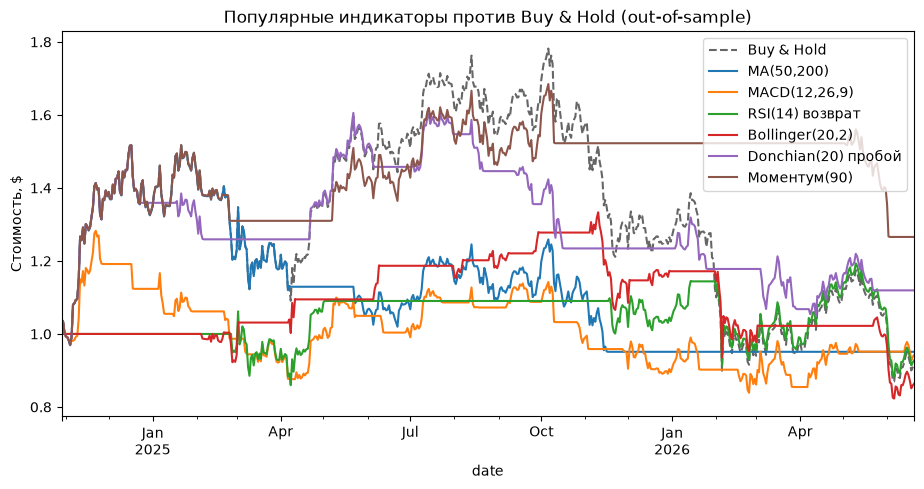

In [37]:
ax = (1 + btc["close"].pct_change().fillna(0.0).loc[split_date:]).cumprod().plot(
    figsize=(11, 5), label="Buy & Hold", linestyle="--", alpha=0.6, color="black")
for s in strategies:
    (1 + run_backtest(btc, s).returns.loc[split_date:]).cumprod().plot(ax=ax, label=s.name)
ax.set_title("Популярные индикаторы против Buy & Hold (out-of-sample)")
ax.set_ylabel("Стоимость, $")
ax.legend()
plt.show()

## Вывод по сравнению индикаторов

**Сигналы примерно взаимозаменяемы.** Разброс между индикаторами на одном периоде — в основном шум: лучший из шести «победил» во многом по удаче, и на другом периоде/активе порядок поменяется. Поэтому **выбирать тот, что лучше всех на тесте, нельзя** — это data-snooping, то самое переобучение.

**Большинство не бьёт «купи и держи» стабильно.** Как и MA на Уровне 1, индикаторы чаще дают не более высокую доходность, а другую форму риска (меньше просадка, меньше время в рынке). Их ценность — в управлении риском, а не в магическом предсказании.

**Как выбирать честно.** Не по результату на тесте, а по принципу: какой сигнал соответствует твоей гипотезе о рынке (тренд vs возврат к среднему), плюс проверка устойчивости на валидации и на нескольких активах. И поверх любого сигнала решающим остаётся **размер позиции и риск-менеджмент** — это мы видели в первом бонусе.

In [38]:
# Time-series кросс-валидация ML-агента: честнее одного сплита.
import numpy as np

WARMUP = 50  # самое длинное окно фичей (mom_50)

def walk_forward_ml(prices, n_splits=5, min_train=400):
    n = len(prices)
    edges = np.linspace(min_train, n, n_splits + 1, dtype=int)
    oos_parts, fold_rows = [], []
    for i in range(n_splits):
        tr_end, te_end = edges[i], edges[i + 1]
        agent = MLAgent(prices.iloc[:tr_end])              # учим только на прошлом
        test_slice = prices.iloc[tr_end - WARMUP:te_end]   # буфер на разогрев фичей
        oos = run_backtest(test_slice, agent).returns.iloc[WARMUP:]
        oos_parts.append(oos)
        fold_rows.append({"фолд": i + 1, **metrics_on(oos)})
    combined = metrics_on(pd.concat(oos_parts))
    print(f"Объединённый OOS (все 5 фолдов): Sharpe {combined['sharpe']:.3f}, "
          f"Sortino {combined['sortino']:.3f}, доходность {combined['total_return']:.1%}")
    return pd.DataFrame(fold_rows).set_index("фолд").round(3)

walk_forward_ml(btc)

Объединённый OOS (все 5 фолдов): Sharpe 0.030, Sortino 0.042, доходность -18.9%


,total_return,CAGR,sharpe,sortino,max_drawdown
фолд,,,,,
1,-0.157,-0.177,-0.145,-0.201,-0.442
2,0.072,0.083,0.626,1.095,-0.099
3,0.479,0.563,1.668,2.956,-0.188
4,0.157,0.181,0.725,1.130,-0.276
5,-0.476,-0.521,-1.751,-2.248,-0.516


In [39]:
# Чувствительность к издержкам: комиссия 0.1% / 0.3% / 0.4%.
cost_rows = []
for c in [0.001, 0.003, 0.004]:
    net, _, _ = universe_backtest(uni, use_risk_agent=True, cost=c)
    cost_rows.append({"издержки": f"{c:.1%}", **metrics_on(net.loc[split_date:])})
pd.DataFrame(cost_rows).set_index("издержки").round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
издержки,,,,,
0.1%,-0.535,-0.372,-0.439,-0.592,-0.751
0.3%,-0.547,-0.382,-0.466,-0.628,-0.757
0.4%,-0.553,-0.387,-0.479,-0.646,-0.760


In [40]:
# === Эконометрический агент: GARCH(1,1) как фильтр режима волатильности ===
from arch import arch_model
import numpy as np
from chf.strategies.base import Strategy

class GarchRegimeAgent(Strategy):
    """GARCH(1,1) прогнозирует волатильность: держим актив в спокойном режиме,
    уходим в кэш при прогнозе 'шторма'. Leak-free: прогноз vol_t зависит только
    от прошлых доходностей."""
    def __init__(self, train_prices, vol_quantile=0.7):
        self.name = "GARCH (vol-режим)"
        r = train_prices["close"].pct_change().dropna() * 100   # в % — так arch стабильнее
        self._mu = r.mean()
        res = arch_model(r, vol="GARCH", p=1, q=1, mean="Constant", dist="normal").fit(disp="off")
        self._omega = res.params["omega"]
        self._alpha = res.params["alpha[1]"]
        self._beta = res.params["beta[1]"]
        self._thresh = np.quantile(res.conditional_volatility, vol_quantile)  # порог "шторма" с train

    def generate_signals(self, prices):
        r = prices["close"].pct_change().dropna() * 100
        eps = (r - self._mu).values
        var = np.empty(len(eps))
        var[0] = self._omega / max(1e-9, 1 - self._alpha - self._beta)
        for t in range(1, len(eps)):
            var[t] = self._omega + self._alpha * eps[t-1]**2 + self._beta * var[t-1]
        vol = pd.Series(np.sqrt(var), index=r.index)
        sig = (vol <= self._thresh).astype(float)   # 1 = спокойно (в позиции), 0 = шторм (кэш)
        return sig.reindex(prices.index).fillna(0.0)

garch = GarchRegimeAgent(train_prices)              # учим GARCH только на train
result_garch = run_backtest(btc, garch)

# Сравнение OOS: эконометрика vs ML vs правило vs пассив
rows = {
    "GARCH (vol-режим)": metrics_on(result_garch.returns.loc[split_date:]),
    "ML (RandomForest)": metrics_on(result_ml.returns.loc[split_date:]),
    "MA (50,200)":       metrics_on(result_ma.returns.loc[split_date:]),
    "Buy & Hold":        metrics_on(test_asset_ret),
}
pd.DataFrame(rows).T.round(3)

,total_return,CAGR,sharpe,sortino,max_drawdown
GARCH (vol-режим),-0.104,-0.065,0.066,0.095,-0.495
ML (RandomForest),-0.226,-0.144,-0.283,-0.401,-0.433
"MA (50,200)",-0.049,-0.030,0.072,0.105,-0.373
Buy & Hold,-0.122,-0.076,0.053,0.077,-0.512
